# USA-NPN — Deciduous Fruit Trees

Pulls Individual Phenometrics from the [USA National Phenology Network](https://www.usanpn.org/data/observational) for a curated set of deciduous **fruit-tree** genera, then runs a few exploratory analyses on the resulting flowering and leaf-out records.

Genera covered (PEP725's fruit-tree set extended with North-American natives that show up in NPN):
*Malus, Pyrus, Prunus, Cydonia, Mespilus, Corylus, Castanea, Juglans, Carya, Diospyros, Asimina, Morus, Punica, Vitis, Vaccinium, Ribes, Rubus, Ficus*.

Phenophases:
- **501 — Open flowers** (closest to PEP725 BBCH_60)
- **371 — Breaking leaf buds** (closest to PEP725 BBCH_11)

The wire-level downloads are cached under `data/observations/usa_npn/raw/` and keyed by parameter hash, so re-runs are free unless the genera/date/phenophase set changes. The deciduous-trees cache produced by [phylogeny_usa_npn.ipynb](phylogeny_usa_npn.ipynb) is shared (different hash though, so a fresh download will happen the first time).

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib import colormaps

from pysephone.paths import get_repo_root

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

## 1. Configuration

USA-NPN observation coverage starts in 2009. We download 2009-01-01 through last full year. Edit `FRUIT_GENERA` to change the species set.

In [2]:
SRC_KEY      = 'usa_npn'
NPN_ROOT     = get_repo_root() / 'data' / 'observations' / 'usa_npn'
RAW_DIR      = NPN_ROOT / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

REQUEST_SRC  = 'pysephone'  # identifies us in USA-NPN logs
NPN_BASE     = 'https://services.usanpn.org/npn_portal'

START_DATE   = '2009-01-01'
END_DATE     = '2024-12-31'

PHENO_FLOWER   = 501  # Open flowers
PHENO_LEAF_BUD = 371  # Breaking leaf buds

# Curated deciduous-fruit-tree genera. Mostly Rosaceae plus a handful of
# other deciduous fruit/nut producers; vines (Vitis) and shrubs (Vaccinium,
# Ribes, Rubus) included since USA-NPN treats them under the same protocol
# and they are commonly grouped as 'fruit crops'.
FRUIT_GENERA = {
    # Rosaceae fruit trees — direct counterparts of PEP725_fruit_trees
    'Malus',     # apple
    'Pyrus',     # pear
    'Prunus',    # cherry / peach / plum / almond / apricot / blackthorn
    'Cydonia',   # quince
    'Mespilus',  # medlar
    # Other deciduous tree fruits / nuts
    'Corylus',     # hazel
    'Castanea',    # chestnut
    'Juglans',     # walnut
    'Carya',       # hickory / pecan
    'Diospyros',   # persimmon
    'Asimina',     # pawpaw
    'Morus',       # mulberry
    'Punica',      # pomegranate
    'Ficus',       # fig
    # Deciduous fruiting shrubs / vines
    'Vitis',       # grape
    'Vaccinium',   # blueberry / cranberry
    'Ribes',       # currant / gooseberry
    'Rubus',       # raspberry / blackberry
}
print(f'{len(FRUIT_GENERA)} fruit genera, {START_DATE} → {END_DATE}')

18 fruit genera, 2009-01-01 → 2024-12-31


## 2. Download species catalogue + phenometrics

We hit two USA-NPN endpoints:

- `species/getSpecies.json` — full species catalogue, then filter by genus.
- `observations/getSummarizedData.json` — the *Individual Phenometrics* product despite the un-obvious name (matches `rnpn::npn_download_individual_phenometrics`). One row per (Site × Individual × Year) per phenophase, with first-yes / last-yes dates.

Each download is cached as a CSV keyed by a SHA-1 of `(species_ids, phenophase, start, end)`.

In [21]:
def fetch_species_table(force: bool = False) -> pd.DataFrame:
    """Fetch the USA-NPN species catalogue (cached as raw/species.csv)."""
    cache = RAW_DIR / 'species.csv'
    if cache.exists() and not force:
        return pd.read_csv(cache)
    url = f'{NPN_BASE}/species/getSpecies.json'
    print(f'GET {url}')
    resp = requests.get(url, params={'request_src': REQUEST_SRC}, timeout=120)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json())
    df.columns = [c.lower() for c in df.columns]
    df.to_csv(cache, index=False)
    print(f'  cached {cache.name}: {len(df):,} species')
    return df


def fetch_individual_phenometrics(species_ids, phenophase_id,
                                   start_date, end_date,
                                   force: bool = False) -> pd.DataFrame:
    """POST the bulk Individual Phenometrics request, cached by parameter hash."""
    species_ids = sorted(int(s) for s in species_ids)
    key = hashlib.sha1(
        f'{species_ids}|{phenophase_id}|{start_date}|{end_date}'.encode()
    ).hexdigest()[:10]
    cache = RAW_DIR / (
        f'individual_phenometrics_{start_date}_{end_date}'
        f'_p{phenophase_id}_{key}.csv'
    )
    if cache.exists() and not force:
        print(f'[cache] {cache.name}')
        return pd.read_csv(cache, low_memory=False)

    url = f'{NPN_BASE}/observations/getSummarizedData.json'
    payload = {
        'request_src': REQUEST_SRC,
        'start_date':  start_date,
        'end_date':    end_date,
    }
    for i, sid in enumerate(species_ids, start=1):
        payload[f'species_id[{i}]'] = sid
    payload['phenophase_id[1]'] = phenophase_id

    print(f'POST {url}')
    print(f'  ({len(species_ids)} species, {start_date}..{end_date}, '
          f'phenophase={phenophase_id})')
    resp = requests.post(url, data=payload, timeout=600)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json())
    df.to_csv(cache, index=False)
    print(f'  -> {len(df):,} rows, saved to {cache.name}')
    return df

In [22]:
df_species = fetch_species_table()
print(f'USA-NPN species catalogue: {len(df_species):,} rows')

mask = df_species['genus'].isin(FRUIT_GENERA)
if 'kingdom' in df_species.columns:
    mask &= (df_species['kingdom'].fillna('Plantae') == 'Plantae')
df_fruit = df_species[mask].copy().reset_index(drop=True)

missing = sorted(FRUIT_GENERA - set(df_fruit['genus']))
if missing:
    print(f'  (no NPN species for: {missing})')

print(f'\nFruit-tree species in catalogue: {len(df_fruit)} '
      f'across {df_fruit["genus"].nunique()} genera')
df_fruit[['species_id', 'genus', 'species', 'common_name', 'family_name']].head(15)

USA-NPN species catalogue: 1,940 rows
  (no NPN species for: ['Mespilus', 'Punica'])

Fruit-tree species in catalogue: 99 across 16 genera


,species_id,genus,species,common_name,family_name
0,724,Castanea,dentata,American chestnut,Fagaceae
1,71,Corylus,americana,American hazelnut,Betulaceae
2,206,Prunus,americana,American plum,Rosaceae
3,1762,Rubus,idaeus,American red raspberry,Rosaceae
4,1208,Malus,spp.,apple,Rosaceae
5,1362,Prunus,armeniaca,apricot,Rosaceae
6,1353,Juglans,major,Arizona walnut,Juglandaceae
7,982,Prunus,maritima,beach plum,Rosaceae
8,72,Corylus,cornuta,beaked hazelnut,Betulaceae
9,802,Asimina,obovata,bigflower pawpaw,Annonaceae


In [23]:
df_flower_raw = fetch_individual_phenometrics(
    species_ids=df_fruit['species_id'].tolist(),
    phenophase_id=PHENO_FLOWER,
    start_date=START_DATE, end_date=END_DATE,
)
df_leaf_raw = fetch_individual_phenometrics(
    species_ids=df_fruit['species_id'].tolist(),
    phenophase_id=PHENO_LEAF_BUD,
    start_date=START_DATE, end_date=END_DATE,
)
print(f'\nOpen flowers (501):       {len(df_flower_raw):>7,} rows')
print(f'Breaking leaf buds (371): {len(df_leaf_raw):>7,} rows')

[cache] individual_phenometrics_2009-01-01_2024-12-31_p501_8e31805a41.csv
[cache] individual_phenometrics_2009-01-01_2024-12-31_p371_eadb4479ca.csv

Open flowers (501):         7,942 rows
Breaking leaf buds (371):  14,606 rows


## 3. Cleaning

USA-NPN encodes missing values as `-9999` in numeric columns. We drop rows whose `first_yes_*` date components fall outside the valid range and convert to a real `datetime` + day-of-year. Both phenophases get the same treatment.

In [24]:
def clean(df_raw: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df_raw.copy()
    n0 = len(df)
    df = df[df['first_yes_month'].between(1, 12)
            & df['first_yes_day'].between(1, 31)
            & df['first_yes_year'].between(2009, 2030)]
    df['first_yes_date'] = pd.to_datetime(
        dict(year=df['first_yes_year'].astype(int),
             month=df['first_yes_month'].astype(int),
             day=df['first_yes_day'].astype(int)),
        errors='coerce',
    )
    df = df.dropna(subset=['first_yes_date'])
    df['doy']  = df['first_yes_date'].dt.dayofyear
    df['year'] = df['first_yes_year'].astype(int)
    # In rare cases USA-NPN duplicates (site, individual, year) — keep the earliest first-yes.
    df = (df.sort_values(['individual_id', 'year', 'doy'])
            .drop_duplicates(subset=['individual_id', 'year'], keep='first'))
    df['phenophase_label'] = label
    print(f'{label:18s}: kept {len(df):,} / {n0:,} rows '
          f'(dropped {n0 - len(df):,})')
    return df


df_flower = clean(df_flower_raw, 'open_flowers')
df_leaf   = clean(df_leaf_raw,   'breaking_leaf_buds')

# Combined long-form frame for cross-phenophase comparisons
df_all = pd.concat([df_flower, df_leaf], ignore_index=True)
df_all['genus_species'] = df_all['genus'] + ' ' + df_all['species']
df_all.head(3)

open_flowers      : kept 6,443 / 7,942 rows (dropped 1,499)
breaking_leaf_buds: kept 9,218 / 14,606 rows (dropped 5,388)


,site_id,latitude,longitude,elevation_in_meters,state,species_id,genus,species,common_name,kingdom,individual_id,phenophase_id,phenophase_description,first_yes_year,first_yes_month,first_yes_day,first_yes_doy,first_yes_julian_date,numdays_since_prior_no,last_yes_year,last_yes_month,last_yes_day,last_yes_doy,last_yes_julian_date,numdays_until_next_no,first_yes_date,doy,year,phenophase_label,genus_species
0,40,43.242199,-88.288902,308,WI,83,Malus,domestica,paradise apple,Plantae,413,501,Open flowers,2009,5,11,131,2454963,6,2009,5,16,136,2454968,-9999,2009-05-11,131,2009,open_flowers,Malus domestica
1,720,38.530819,-77.234512,12,MD,80,Juglans,nigra,black walnut,Plantae,449,501,Open flowers,2009,4,19,109,2454941,7,2009,4,19,109,2454941,-9999,2009-04-19,109,2009,open_flowers,Juglans nigra
2,720,38.530819,-77.234512,12,MD,80,Juglans,nigra,black walnut,Plantae,450,501,Open flowers,2009,4,19,109,2454941,22,2009,4,19,109,2454941,-9999,2009-04-19,109,2009,open_flowers,Juglans nigra


## 4. Coverage

How many records, sites, individuals, and years per genus? Which species dominate the dataset?

In [25]:
def coverage_by_genus(df: pd.DataFrame) -> pd.DataFrame:
    out = (df.groupby('genus')
             .agg(records      =('doy', 'size'),
                  individuals  =('individual_id', 'nunique'),
                  sites        =('site_id', 'nunique'),
                  species      =('species_id', 'nunique'),
                  years        =('year', 'nunique'),
                  first_year   =('year', 'min'),
                  last_year    =('year', 'max'))
             .sort_values('records', ascending=False))
    return out

print('=== Open flowers (501) ===')
cov_flower = coverage_by_genus(df_flower)
print(cov_flower.to_string())
print('\n=== Breaking leaf buds (371) ===')
cov_leaf = coverage_by_genus(df_leaf)
print(cov_leaf.to_string())

=== Open flowers (501) ===
           records  individuals  sites  species  years  first_year  last_year
genus                                                                        
Vaccinium     1710          627    247       21     17        2009       2026
Prunus        1605          653    396       17     16        2009       2024
Carya          546          197     82        5     16        2009       2024
Rubus          462          226    123       12     13        2012       2024
Corylus        426          145     65        2     14        2011       2024
Malus          405          232    142        3     16        2009       2024
Juglans        394          137     68        2     16        2009       2024
Ribes          307          173    108        9     13        2012       2024
Asimina        197          101     43        3     12        2013       2024
Pyrus          173           99     78        2     11        2014       2024
Diospyros       64           28     1

In [26]:
TOP_N = 15
top_species = (df_flower
               .groupby(['genus', 'species', 'common_name'])
               .size().rename('records')
               .sort_values(ascending=False)
               .head(TOP_N).reset_index())
print(f'Top {TOP_N} fruit-tree species by flowering-record count:')
print(top_species.to_string(index=False))

Top 15 fruit-tree species by flowering-record count:
    genus       species        common_name  records
   Prunus      serotina       black cherry      693
Vaccinium   vitis-idaea        lingonberry      608
  Juglans         nigra       black walnut      350
  Corylus       cornuta    beaked hazelnut      341
    Malus          spp.              apple      304
Vaccinium    uliginosum      bog blueberry      296
Vaccinium    corymbosum highbush blueberry      260
   Prunus    virginiana        chokecherry      255
    Carya         ovata   shagbark hickory      233
    Carya        glabra     pignut hickory      190
  Asimina       triloba             pawpaw      170
    Rubus   spectabilis        salmonberry      162
Vaccinium   parvifolium    red huckleberry      159
Vaccinium angustifolium  lowbush blueberry      149
   Prunus       persica              peach      138


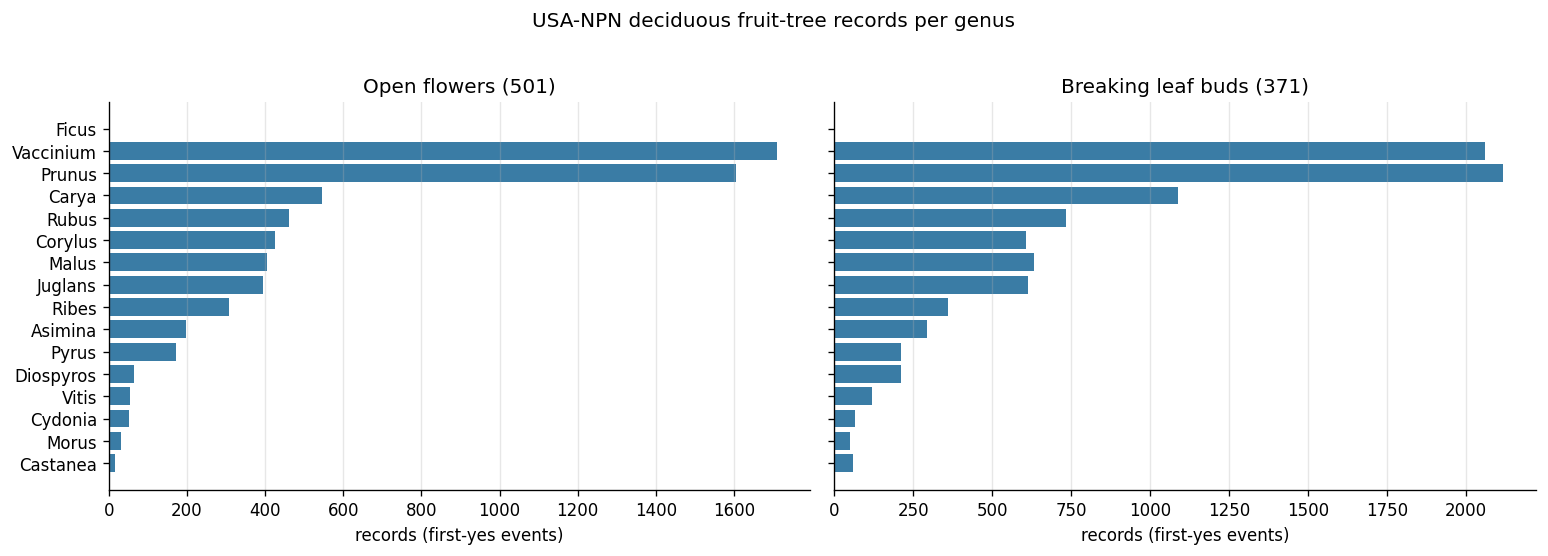

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.3 * len(cov_flower))),
                          sharey=True)
for ax, (label, cov) in zip(axes, [('Open flowers (501)', cov_flower),
                                    ('Breaking leaf buds (371)', cov_leaf)]):
    cov_sorted = cov.sort_values('records')
    ax.barh(cov_sorted.index, cov_sorted['records'], color='#3a7ca5')
    ax.set_title(label)
    ax.set_xlabel('records (first-yes events)')
    ax.grid(axis='x', alpha=0.3)
fig.suptitle('USA-NPN deciduous fruit-tree records per genus', y=1.02)
fig.tight_layout()
plt.show()

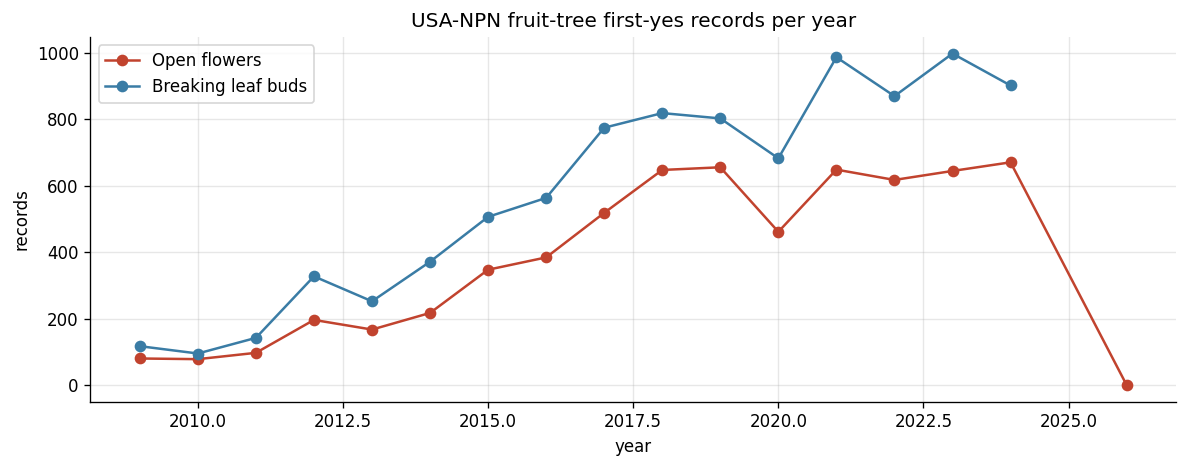

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, df, color in [('Open flowers',       df_flower, '#c1432e'),
                          ('Breaking leaf buds', df_leaf,   '#3a7ca5')]:
    yearly = df.groupby('year').size()
    ax.plot(yearly.index, yearly.values, marker='o', label=label, color=color)
ax.set_xlabel('year')
ax.set_ylabel('records')
ax.set_title('USA-NPN fruit-tree first-yes records per year')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 5. Geographic distribution

Lat/lon scatter of all observation sites, coloured by genus, plus per-state counts.

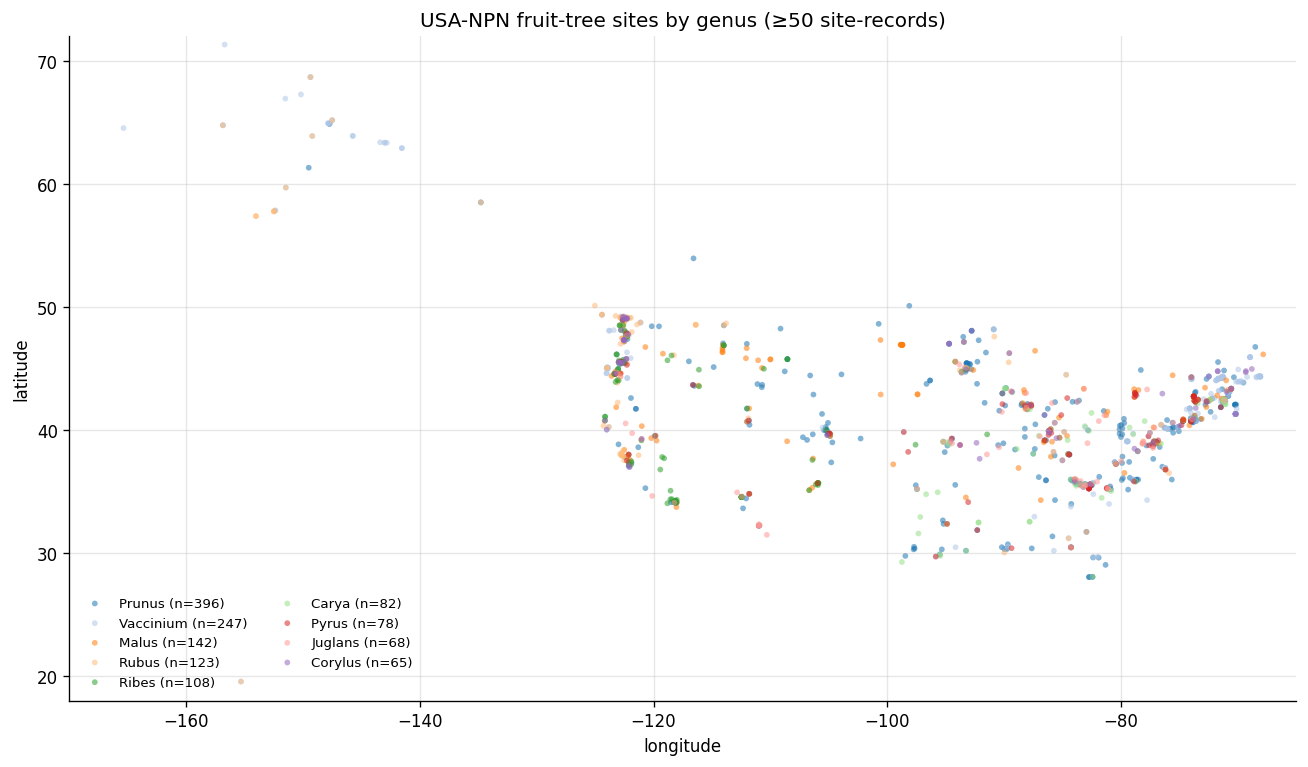

In [29]:
MIN_GENUS_FOR_PLOT = 50
geo = df_flower[['site_id', 'latitude', 'longitude', 'genus', 'state']].drop_duplicates(
    subset=['site_id', 'genus']
)
genus_counts = geo['genus'].value_counts()
plot_genera = genus_counts[genus_counts >= MIN_GENUS_FOR_PLOT].index.tolist()

cmap = colormaps.get_cmap('tab20')
colors = {g: cmap(i % cmap.N) for i, g in enumerate(plot_genera)}

fig, ax = plt.subplots(figsize=(11, 6.5))
for g in plot_genera:
    sub = geo[geo['genus'] == g]
    ax.scatter(sub['longitude'], sub['latitude'],
               s=12, alpha=0.55, label=f'{g} (n={len(sub)})',
               color=colors[g], edgecolors='none')
ax.set_xlim(-170, -65)
ax.set_ylim(18, 72)
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.set_title(f'USA-NPN fruit-tree sites by genus (≥{MIN_GENUS_FOR_PLOT} site-records)')
ax.grid(alpha=0.3)
ax.legend(loc='lower left', fontsize=8, ncol=2, frameon=False)
fig.tight_layout()
plt.show()

In [30]:
state_counts = (df_flower.groupby('state').size()
                          .rename('flower_records')
                          .sort_values(ascending=False))
print('Top 12 states by flowering-record count:')
print(state_counts.head(12).to_string())

Top 12 states by flowering-record count:
state
NY    689
MA    617
CA    546
WA    384
VA    383
AK    348
NH    344
OR    269
NC    205
MN    202
ME    194
KS    193


## 6. Phenology distributions

Day-of-year distributions of first-flowering and first-leaf for the top fruit species.

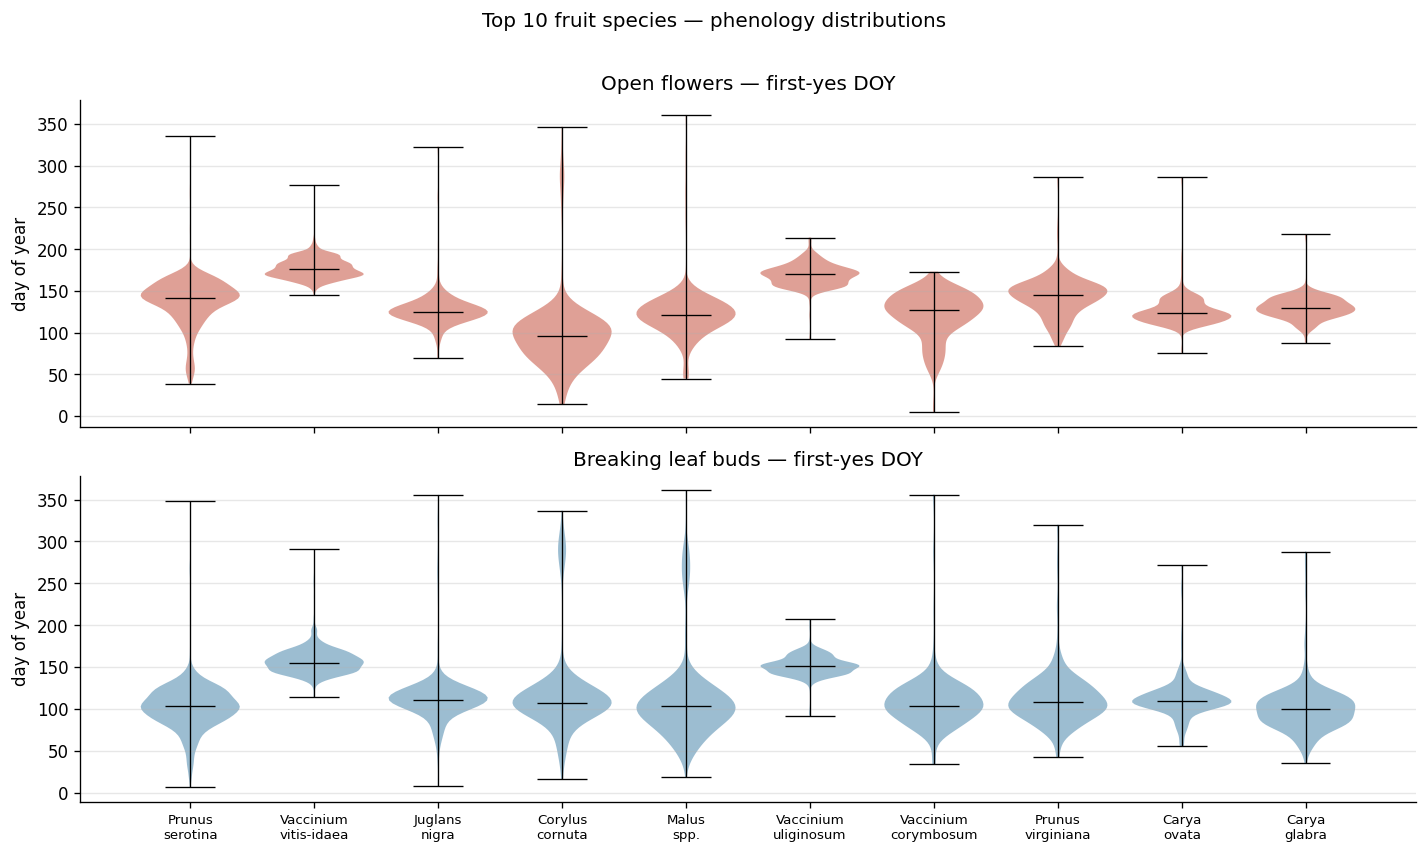

In [31]:
TOP_K = 10
top_keys = (df_flower.groupby(['genus', 'species']).size()
                       .sort_values(ascending=False)
                       .head(TOP_K).index)

def _slice(df, keys):
    out = []
    for g, s in keys:
        v = df[(df['genus'] == g) & (df['species'] == s)]['doy'].values
        out.append(v)
    return out

labels = [f'{g}\n{s}' for g, s in top_keys]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, (df, title, color) in zip(
    axes,
    [(df_flower, 'Open flowers — first-yes DOY',       '#c1432e'),
     (df_leaf,   'Breaking leaf buds — first-yes DOY', '#3a7ca5')],
):
    series = _slice(df, top_keys)
    parts = ax.violinplot(series, showmedians=True, widths=0.8)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.5); pc.set_edgecolor('none')
    for k in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
        if k in parts:
            parts[k].set_color('black'); parts[k].set_linewidth(0.8)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=0, fontsize=8)
    ax.set_ylabel('day of year')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle(f'Top {TOP_K} fruit species — phenology distributions', y=1.01)
fig.tight_layout()
plt.show()

## 7. Latitude vs flowering DOY

Within a species, first-flowering should slide later as you move north. Slopes are reported in days-of-year per degree-latitude — comparable across species.

In [32]:
MIN_RECORDS = 80
rows = []
for (g, sp), sub in df_flower.groupby(['genus', 'species']):
    if len(sub) < MIN_RECORDS or sub['latitude'].std() < 1.0:
        continue
    slope, intercept = np.polyfit(sub['latitude'], sub['doy'], 1)
    r = np.corrcoef(sub['latitude'], sub['doy'])[0, 1]
    rows.append({
        'genus':  g, 'species': sp,
        'n':      len(sub),
        'lat_min': sub['latitude'].min(), 'lat_max': sub['latitude'].max(),
        'doy_per_deg_lat': slope, 'r': r,
    })
lat_slopes = (pd.DataFrame(rows)
                .sort_values('doy_per_deg_lat', ascending=False)
                .reset_index(drop=True))
print(f'Species with ≥{MIN_RECORDS} flowering records and lat range > 1°:')
print(lat_slopes.round(2).to_string(index=False))

Species with ≥80 flowering records and lat range > 1°:
    genus       species   n  lat_min  lat_max  doy_per_deg_lat     r
  Asimina       triloba 170    32.54    47.76             5.31  0.74
   Prunus      serotina 693    28.04    47.56             5.02  0.65
    Carya         ovata 233    29.77    43.40             4.64  0.56
    Ribes    sanguineum 107    37.19    48.92             4.46  0.52
Vaccinium    corymbosum 260    30.18    59.68             4.11  0.47
Vaccinium angustifolium 149    29.71    48.17             3.89  0.32
   Prunus       persica 138    29.63    43.58             3.83  0.55
    Carya        glabra 190    28.06    42.46             3.76  0.41
   Prunus     americana  91    29.62    48.61             3.48  0.25
    Rubus       ursinus  92    34.14    48.92             3.23  0.25
  Corylus       cornuta 341    36.98    49.21             3.08  0.16
    Rubus   spectabilis 162    37.80    58.48             2.91  0.45
  Juglans         nigra 350    30.45    47.66   

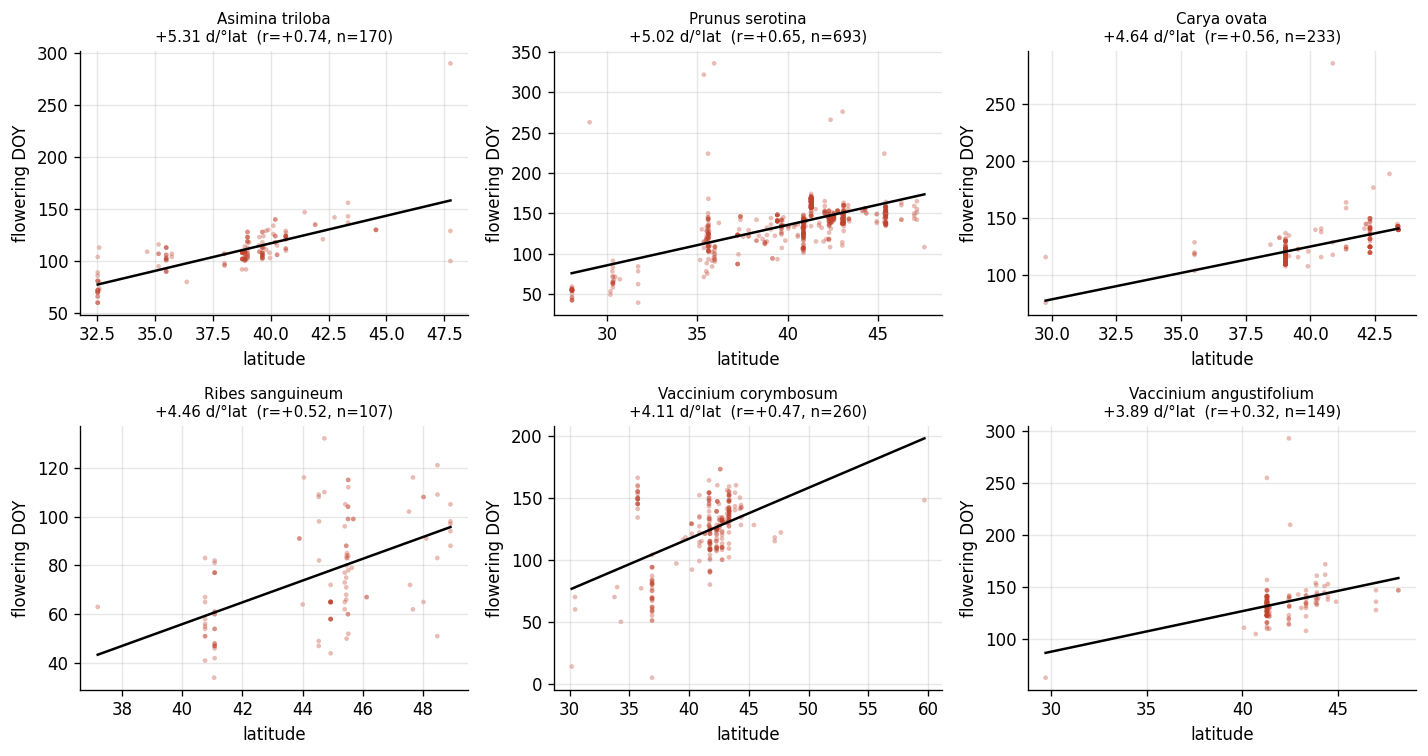

In [33]:
PLOT_TOP = 6
to_plot = lat_slopes.iloc[:PLOT_TOP]
if len(to_plot):
    n = len(to_plot)
    cols = 3
    rows_n = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(4 * cols, 3.2 * rows_n),
                              sharey=False)
    axes = np.atleast_2d(axes).flatten()
    for ax, row in zip(axes, to_plot.itertuples()):
        sub = df_flower[(df_flower['genus'] == row.genus)
                        & (df_flower['species'] == row.species)]
        ax.scatter(sub['latitude'], sub['doy'],
                   s=8, alpha=0.35, color='#c1432e', edgecolors='none')
        x = np.linspace(sub['latitude'].min(), sub['latitude'].max(), 50)
        ax.plot(x, row.doy_per_deg_lat * x
                + (sub['doy'].mean() - row.doy_per_deg_lat * sub['latitude'].mean()),
                color='black', lw=1.5)
        ax.set_title(f'{row.genus} {row.species}\n'
                     f'{row.doy_per_deg_lat:+.2f} d/°lat  (r={row.r:+.2f}, n={row.n})',
                     fontsize=9)
        ax.set_xlabel('latitude'); ax.set_ylabel('flowering DOY')
        ax.grid(alpha=0.3)
    for ax in axes[len(to_plot):]:
        ax.axis('off')
    fig.tight_layout()
    plt.show()
else:
    print('No species met the lat-range / record threshold.')

## 8. Year-over-year shifts

Linear trend in mean flowering DOY across years for each well-sampled species. Negative slopes = earlier flowering over time. The signal here is noisy — sites enter and leave the dataset every year, so this is descriptive rather than a true climate trend.

In [34]:
MIN_YEARS    = 8
MIN_PER_YEAR = 5
rows = []
for (g, sp), sub in df_flower.groupby(['genus', 'species']):
    yearly = sub.groupby('year')['doy'].agg(['mean', 'size'])
    yearly = yearly[yearly['size'] >= MIN_PER_YEAR]
    if len(yearly) < MIN_YEARS:
        continue
    slope, _ = np.polyfit(yearly.index.values, yearly['mean'].values, 1)
    r = np.corrcoef(yearly.index.values, yearly['mean'].values)[0, 1]
    rows.append({
        'genus':  g, 'species': sp,
        'years_used': len(yearly),
        'total_records': int(yearly['size'].sum()),
        'doy_per_year': slope, 'r': r,
    })
year_trends = (pd.DataFrame(rows)
                 .sort_values('doy_per_year')
                 .reset_index(drop=True))
print(f'Species with ≥{MIN_YEARS} years (each ≥{MIN_PER_YEAR} records):')
print(year_trends.round(2).to_string(index=False))

Species with ≥8 years (each ≥5 records):
    genus       species  years_used  total_records  doy_per_year     r
  Corylus     americana           8             74         -6.70 -0.61
  Corylus       cornuta          11            339         -2.06 -0.31
  Asimina       triloba          11            166         -1.47 -0.52
    Malus          spp.          10            301         -1.32 -0.40
Vaccinium    uliginosum          11            287         -0.75 -0.41
Vaccinium angustifolium          10            149         -0.53 -0.36
  Juglans         nigra          15            347         -0.52 -0.19
   Prunus    virginiana          16            255         -0.32 -0.16
   Prunus     americana          12             76         -0.19 -0.04
    Ribes        aureum          10             98         -0.16 -0.04
    Ribes    sanguineum          13            107          0.16  0.04
Vaccinium   parvifolium          10            149          0.18  0.06
Vaccinium   vitis-idaea          14 

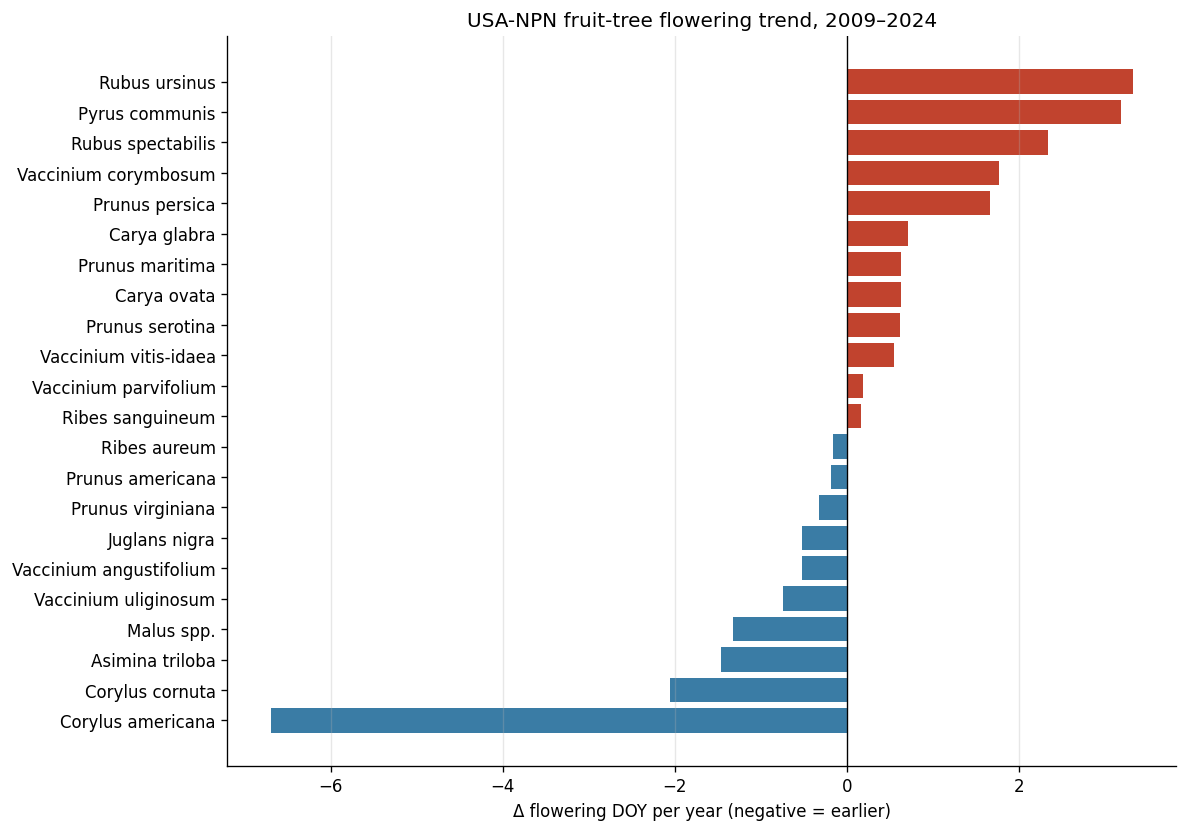

In [35]:
if len(year_trends):
    fig, ax = plt.subplots(figsize=(10, max(3, 0.32 * len(year_trends))))
    yt = year_trends.copy()
    yt['label'] = yt['genus'] + ' ' + yt['species']
    yt = yt.sort_values('doy_per_year')
    colors = ['#3a7ca5' if v < 0 else '#c1432e' for v in yt['doy_per_year']]
    ax.barh(yt['label'], yt['doy_per_year'], color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Δ flowering DOY per year (negative = earlier)')
    ax.set_title('USA-NPN fruit-tree flowering trend, 2009–2024')
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('No species met the year-trend threshold.')

## 9. Leaf-out → flowering interval

Match individual + year between the two phenophases and look at the gap from breaking-leaf-bud to open-flower. For some fruit trees (Prunus, Malus) flowering precedes full leaf expansion, so the interval can be small or even negative.

In [36]:
join_cols = ['individual_id', 'year', 'genus', 'species', 'common_name']
merged = df_leaf[join_cols + ['doy']].rename(columns={'doy': 'doy_leaf'}).merge(
    df_flower[join_cols + ['doy']].rename(columns={'doy': 'doy_flower'}),
    on=join_cols, how='inner',
)
merged['interval'] = merged['doy_flower'] - merged['doy_leaf']
print(f'Paired observations (same individual + same year, both phenophases): '
      f'{len(merged):,}')

MIN_PAIRS = 30
summary = (merged.groupby(['genus', 'species'])
                  .agg(n_pairs=('interval', 'size'),
                       median_interval=('interval', 'median'),
                       mean_interval=('interval', 'mean'),
                       p25=('interval', lambda v: np.percentile(v, 25)),
                       p75=('interval', lambda v: np.percentile(v, 75)))
                  .query('n_pairs >= @MIN_PAIRS')
                  .sort_values('median_interval'))
print(f'\nSpecies with ≥{MIN_PAIRS} paired observations '
      f'(median interval, days from leaf-bud to flower):')
print(summary.round(1).to_string())

Paired observations (same individual + same year, both phenophases): 5,588

Species with ≥30 paired observations (median interval, days from leaf-bud to flower):
                         n_pairs  median_interval  mean_interval   p25   p75
genus     species                                                           
Corylus   americana           70            -16.0           -7.8 -27.8  -7.2
          cornuta            315             -9.0          -11.9 -27.0   0.0
Prunus    armeniaca           32             -1.5          -12.5 -13.2   0.0
          maritima           100              0.0            0.2  -4.0   0.0
Pyrus     calleryana          56              0.0           -0.6   0.0   7.0
Prunus    serrulata           58              0.0            2.9   0.0   6.5
Ribes     aureum              83              0.0            9.8   0.0  28.0
Vaccinium ovatum              40              0.0            1.0   0.0  13.0
Prunus    persica            126              2.5            7.2   0

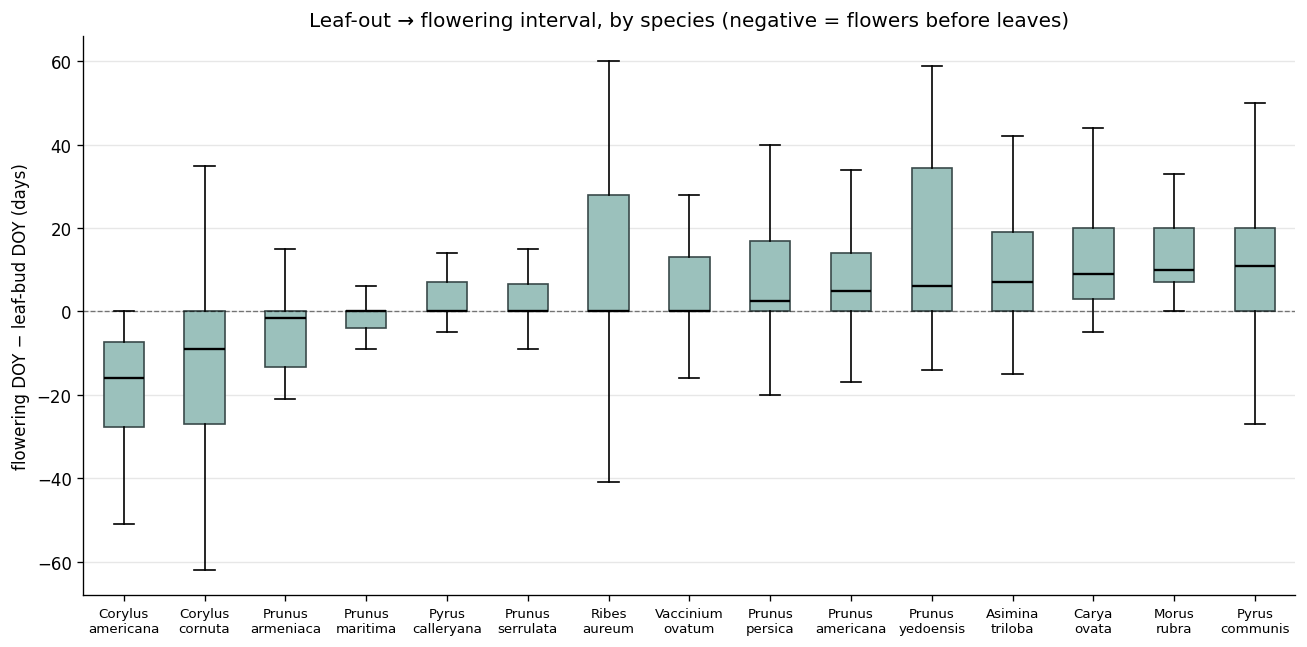

In [37]:
if len(summary):
    keys_for_plot = summary.head(15).index
    series = [merged[(merged['genus'] == g) & (merged['species'] == sp)]['interval'].values
              for g, sp in keys_for_plot]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    bp = ax.boxplot(series, vert=True, showfliers=False, patch_artist=True,
                     medianprops=dict(color='black', lw=1.4))
    for patch in bp['boxes']:
        patch.set_facecolor('#9bc1bc'); patch.set_edgecolor('#3a4a4a')
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(range(1, len(keys_for_plot) + 1))
    ax.set_xticklabels([f'{g}\n{sp}' for g, sp in keys_for_plot],
                       rotation=0, fontsize=8)
    ax.set_ylabel('flowering DOY − leaf-bud DOY (days)')
    ax.set_title('Leaf-out → flowering interval, by species '
                 '(negative = flowers before leaves)')
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('No species met the paired-observation threshold.')

## 10. Summary

What was downloaded and what's available for downstream modelling.

In [38]:
print('=' * 70)
print(f'USA-NPN deciduous fruit-tree pull, {START_DATE} → {END_DATE}')
print('=' * 70)
print(f'Catalogue species (post-genus filter): {len(df_fruit)}')
print(f'Genera covered:                        {df_fruit["genus"].nunique()}')
print()
print(f'Open-flower records:        {len(df_flower):>7,}')
print(f'Breaking-leaf-bud records:  {len(df_leaf):>7,}')
print(f'Paired (individual × year): {len(merged):>7,}')
print()
print(f'Distinct sites:        {pd.concat([df_flower["site_id"], df_leaf["site_id"]]).nunique():,}')
print(f'Distinct individuals:  {pd.concat([df_flower["individual_id"], df_leaf["individual_id"]]).nunique():,}')
print(f'Year coverage:         {df_all["year"].min()} – {df_all["year"].max()}')
print()
print('Cached files:')
for p in sorted(RAW_DIR.glob('individual_phenometrics_*.csv')):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.0f} KiB)')

USA-NPN deciduous fruit-tree pull, 2009-01-01 → 2024-12-31
Catalogue species (post-genus filter): 99
Genera covered:                        16

Open-flower records:          6,443
Breaking-leaf-bud records:    9,218
Paired (individual × year):   5,588

Distinct sites:        1,816
Distinct individuals:  4,202
Year coverage:         2009 – 2026

Cached files:
  individual_phenometrics_2009-01-01_2024-12-31_p371_8a5fcacb76.csv  (2226 KiB)
  individual_phenometrics_2009-01-01_2024-12-31_p371_eadb4479ca.csv  (2207 KiB)
  individual_phenometrics_2009-01-01_2024-12-31_p501_8e31805a41.csv  (1157 KiB)
  individual_phenometrics_2009-01-01_2024-12-31_p501_d562cd1765.csv  (873 KiB)
  individual_phenometrics_2009-01-01_2024-12-31_p501_f9d0fe99db.csv  (6557 KiB)
